In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [38]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# ***PS1***

# **Step 1 — Load data**

In [39]:
BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

features_path = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
classes_path  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
edges_path    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

df_features = pd.read_csv(features_path, header=None)
df_classes  = pd.read_csv(classes_path)
df_edges    = pd.read_csv(edges_path)

print(df_features.shape, df_classes.shape, df_edges.shape)
df_features.head()

(203769, 167) (203769, 2) (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

# **Step 2 — Rename columns and prepare node table**

In [40]:
# Gán tên cho cột
feature_cols = ["txId", "time_step"] + [f"f_{i}" for i in range(2, df_features.shape[1])]
df_features.columns = feature_cols

df_nodes = df_features[["txId", "time_step"]].copy()

class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

df_classes["class"] = df_classes["class"].astype(str)  #Chuẩn hóa kiểu dữ liệu
df_classes["class_label"] = df_classes["class"].map(class_map)  #Map label

# merge node với label
df_nodes = df_nodes.merge(df_classes, on="txId", how="left")
# Gộp:        df_nodes (txId, time_step)               df_classes (txId, label)

print(df_nodes["class_label"].value_counts(dropna=False))
df_nodes.head()

class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


# **Step 3 — Build directed graph**

In [41]:
# Tạo một directed graph (đồ thị có hướng) bằng NetworkX
G = nx.DiGraph()

# add all nodes first
G.add_nodes_from(df_nodes["txId"].tolist())

# add directed edges
edge_list = list(zip(df_edges["txId1"], df_edges["txId2"]))  #Transaction 2 sử dụng output từ transaction 1
G.add_edges_from(edge_list)

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")

print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
# 49 components = 49 time steps => KHÔNG có edge nối giữa các time step
# G = G₁ ∪ G₂ ∪ G₃ ... G₄₉

Number of nodes: 203,769
Number of edges: 234,355
Weakly connected components: 49


# **Step 4 — Compute PS1 metrics (label-free)**

Metrics:
- in_degree
- out_degree
- total_degree
- asymmetry
- abs_asymmetry

In [42]:
in_deg_dict = dict(G.in_degree())
out_deg_dict = dict(G.out_degree())

# Tạo DataFrame để xem
degree_df = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_degree": [in_deg_dict[n] for n in G.nodes()],
    "out_degree": [out_deg_dict[n] for n in G.nodes()],
})

degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

degree_df["asymmetry"] = np.where(
    degree_df["total_degree"] > 0,       #tránh chia cho 0
    (degree_df["in_degree"] - degree_df["out_degree"]) / degree_df["total_degree"],
    np.nan
)

degree_df["abs_asymmetry"] = degree_df["asymmetry"].abs()

degree_df.head()


degree_df.to_csv("degree_metrics.csv", index=False)  # ịn ra file kết quả nè

# **Step 5 — Global graph statistics (label-free)**

In [43]:
global_stats = degree_df[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].describe()
display(global_stats)

pure_sinks = ((degree_df["in_degree"] > 0) & (degree_df["out_degree"] == 0)).mean()
pure_sources = ((degree_df["out_degree"] > 0) & (degree_df["in_degree"] == 0)).mean()

print(f"Fraction of pure sinks   (in>0, out=0): {pure_sinks:.4f}")
print(f"Fraction of pure sources (out>0, in=0): {pure_sources:.4f}")

,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry
count,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000
mean,1.150101,1.150101,2.300203,-0.108612,0.521818
std,3.911132,1.894740,4.328377,0.687363,0.460401
min,0.000000,0.000000,1.000000,-1.000000,0.000000
25%,0.000000,1.000000,1.000000,-1.000000,0.000000
50%,1.000000,1.000000,2.000000,0.000000,0.333333
75%,1.000000,1.000000,2.000000,0.000000,1.000000
max,284.000000,472.000000,473.000000,1.000000,1.000000


Fraction of pure sinks   (in>0, out=0): 0.1837
Fraction of pure sources (out>0, in=0): 0.2715


Pure sinks (in > 0, out = 0) = 18.37%
~18% transaction là end point
(không được spend tiếp trong graph)

Pure sources (out > 0, in = 0) = 27.15%
~27% transaction là start point
(không có input trong graph)

std >> mean

phân phối rất lệch (skewed)
có outliers cực lớn 

std asymmetry ≈ 0.68 => rất lớn (gần 1)
nhiều node cực lệch
nhiều node gần ±1



<Axes: >

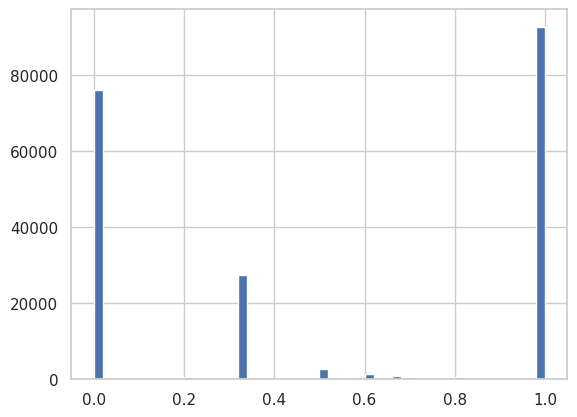

In [44]:


degree_df["abs_asymmetry"].hist(bins=50)


# **Step 6 — Merge metrics with labels for post-hoc evaluation**

In [45]:
# Gán label vào kết quả bên trên
ps1_df = degree_df.merge(
    df_nodes[["txId", "time_step", "class_label"]],
    on="txId",
    how="left"
)

print(ps1_df.shape)   # kiểm tra shape, Số node KHÔNG thay đổi
print(ps1_df["class_label"].value_counts(dropna=False))     # Distribution của label
ps1_df.head()

(203769, 8)
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry,time_step,class_label
0,230425980,1,1,2,0.000000,0.000000,1,unknown
1,5530458,1,1,2,0.000000,0.000000,1,unknown
2,232022460,1,2,3,-0.333333,0.333333,1,unknown
3,232438397,160,1,161,0.987578,0.987578,1,licit
4,230460314,2,8,10,-0.600000,0.600000,1,unknown


# **Step 7 — Group statistics by class**

In [46]:
group_stats = ps1_df.groupby("class_label")[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].agg(
    ["count", "mean", "median", "std"]
)

display(group_stats)

in_degree                            out_degree                   \
                count      mean median       std      count      mean median   
class_label                                                                    
illicit          4545  1.269967    1.0  7.215218       4545  0.741694    1.0   
licit           42019  1.909398    1.0  7.122538      42019  1.185821    1.0   
unknown        157205  0.943685    1.0  2.136958     157205  1.152362    1.0   

                      total_degree                            asymmetry  \
                  std        count      mean median       std     count   
class_label                                                               
illicit      0.571620         4545  2.011661    1.0  7.177521      4545   
licit        3.246769        42019  3.095219    2.0  7.782942     42019   
unknown      1.349530       157205  2.096047    2.0  2.528148    157205   

                                       abs_asymmetry                      \
                 mean median       std         count      mean    median   
class_label                                                                
illicit      0.056396    0.0  0.771688          4545  0.610412  1.000000   
licit       -0.069129    0.0  0.785764         42019  0.662210  1.000000   
unknown     -0.123936    0.0  0.654778        157205  0.481732  0.333333   

                       
                  std  
class_label            
illicit      0.475394  
licit        0.428570  
unknown      0.460464

> **Insight 4 — abs_asymmetry không phải signal tốt**
Evidence:
abs_asymmetry:
illicit = 0.61
licit = 0.66 (cao hơn)

👉 Diễn giải:

Độ lệch (magnitude) KHÔNG phân biệt được illicit

👉 Nhưng:

Direction (dấu + / -) mới quan trọng

**Illicit = “accumulator pattern”**
Evidence:
in_degree:
illicit = 1.27
licit = 1.09
out_degree:
illicit = 0.74
licit = 1.19

👉 Diễn giải:

Illicit transactions có xu hướng:

nhận nhiều hơn
chi ra ít hơn

👉 Đây chính là:

accumulation behavior (gom tiền)

**Asymmetry direction phân biệt rõ**
Evidence:
asymmetry (mean):
illicit = +0.056
licit = -0.069
unknown = -0.124

👉 Diễn giải:

illicit → positive asymmetry → in > out
licit → negative asymmetry → out > in

👉 Kết luận:

Direction của asymmetry là tín hiệu phân biệt mạnh

**Illicit KHÔNG phải hub**
Evidence:
total_degree:
illicit ≈ 2.01
licit ≈ 3.10

👉 Diễn giải:

Illicit transactions có ít kết nối hơn licit

# **Step 8 — Mann–Whitney U test + rank-biserial correlation**

In [47]:
# Hàm effect size, rank-biserial correlation (RBC) đo độ mạnh của sự khác biệt (đổi từ u_stat qua cái nì)
# >0 nhóm 1 > nhóm 2 , <0  nhóm 1 < nhóm 2, gần ±1  khác rất mạnh

def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def mannwhitney_test(df, metric, group_col="class_label", g1="licit", g2="illicit"):
    x = df.loc[df[group_col] == g1, metric].dropna()
    y = df.loc[df[group_col] == g2, metric].dropna()

# Tính effect size
# u = số lần một phần tử nhóm này thắng phần tử nhóm kia (rank)
    # số lần giá trị trong x < y
    u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
    # Chạy Mann–Whitney U test hai phía u_stat: thống kê U và p_value
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    return {
        "metric": metric,
        "n_licit": len(x),
        "n_illicit": len(y),
        "median_licit": x.median(),
        "median_illicit": y.median(),
        "u_stat": u_stat,
        "p_value": p_val,
        "rank_biserial_corr": rbc
    }

# Lặp qua từng metric, chạy test, rồi gom kết quả thành DataFrame
metrics_to_test = ["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]

mw_results = pd.DataFrame([mannwhitney_test(ps1_df, m) for m in metrics_to_test])
display(mw_results)

,metric,n_licit,n_illicit,median_licit,median_illicit,u_stat,p_value,rank_biserial_corr
0,in_degree,42019,4545,1.0,1.0,100682787.5,5.552428e-11,-0.054401
1,out_degree,42019,4545,1.0,1.0,113640517.5,1.441678e-118,-0.190100
2,total_degree,42019,4545,2.0,1.0,119280225.5,6.844822e-188,-0.249162
3,asymmetry,42019,4545,0.0,0.0,86621821.5,1.628183e-26,0.092853
4,abs_asymmetry,42019,4545,1.0,1.0,99639397.0,5.797299e-08,-0.043474


toàn licit < illicit thôi nhưng mà assymetry thì licit > illicit

Dataset rất lớn (~40k vs 4k)
→ p-value luôn nhỏ

❗ → KHÔNG dùng p-value để kết luận chính

indegree RBC ≈ -0.054 effect size rất nhỏ (~0.05)
gần như không khác biệt thực tế


total_degree RBC ≈ -0.25
median: 2 vs 1
effect size lớn nhất trong bảng
licit có nhiều kết nối hơn
💥 illicit:
ít kết nối hơn
ít “active” hơn


asymmetryRBC ≈ +0.093

effect size nhỏ nhưng có hướng rõ
dương → illicit lệch hơn
💥 illicit có xu hướng mất cân bằng hơn

# **Step 9 — Enrichment analysis**

**9.1 Baseline illicit rate among labeled nodes**

In [48]:
labeled_df = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()

baseline_illicit = (labeled_df["class_label"] == "illicit").mean()
print(f"Baseline illicit rate (labeled only): {baseline_illicit:.4f}")

Baseline illicit rate (labeled only): 0.0976


**9.2 Helper function for enrichment**

In [49]:
# Hàm enrichment_ratio
# df_subset: 1 nhóm node mk chọn (ví dụ asymmetry cao)
def enrichment_ratio(df_subset, class_col="class_label", positive_label="illicit", baseline=0.0):
 
    # lọc node có label   
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()
    
    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan
        }

# tính illicit rate trong subset
    illicit_rate_subset = (labeled_subset[class_col] == positive_label).mean()

# tính enrichment
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    
    return {
        "n_subset_labeled": len(labeled_subset),
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment
    }

**9.3 Extreme imbalance / accumulator / distributor**

In [50]:
threshold_results = []

# extreme imbalance
subset_extreme = ps1_df[ps1_df["asymmetry"] > 0.95]
res_extreme = enrichment_ratio(subset_extreme, baseline=baseline_illicit)
res_extreme["rule"] = "asymmetry > 0.95"
threshold_results.append(res_extreme)

# accumulators
subset_acc = ps1_df[ps1_df["asymmetry"] > 0.5]
res_acc = enrichment_ratio(subset_acc, baseline=baseline_illicit)
res_acc["rule"] = "asymmetry > 0.5"
threshold_results.append(res_acc)

# distributors
subset_dist = ps1_df[ps1_df["asymmetry"] < -0.5]
res_dist = enrichment_ratio(subset_dist, baseline=baseline_illicit)
res_dist["rule"] = "asymmetry < -0.5"
threshold_results.append(res_dist)

enrichment_df = pd.DataFrame(threshold_results)[[
    "rule", "n_subset_labeled", "illicit_rate_subset", "baseline_illicit_rate", "enrichment_ratio"
]]

display(enrichment_df)

,rule,n_subset_labeled,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio
0,asymmetry > 0.95,11861,0.124863,0.097608,1.279234
1,asymmetry > 0.5,13372,0.112100,0.097608,1.148475
2,asymmetry < -0.5,15575,0.077368,0.097608,0.792639


a > 0.8 ko xài | |
vẽ chart 3 trục 
Ox 3 threadho
line + bar => xem cắt ở đâu

Baseline illicit rate = 0.0976


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,-1.00,left (distributor side),asymmetry <= -1.00,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692
1,-0.95,left (distributor side),asymmetry <= -0.95,55333,15162,1205,1479.926338,0.079475,0.097608,0.814230,-274.926338
2,-0.90,left (distributor side),asymmetry <= -0.90,55377,15167,1205,1480.414376,0.079449,0.097608,0.813961,-275.414376
3,-0.85,left (distributor side),asymmetry <= -0.85,55468,15196,1205,1483.244996,0.079297,0.097608,0.812408,-278.244996
4,-0.80,left (distributor side),asymmetry <= -0.80,55641,15260,1205,1489.491882,0.078965,0.097608,0.809001,-284.491882
5,-0.75,left (distributor side),asymmetry <= -0.75,55840,15318,1205,1495.153123,0.078666,0.097608,0.805938,-290.153123
6,-0.70,left (distributor side),asymmetry <= -0.70,56050,15369,1205,1500.131110,0.078405,0.097608,0.803263,-295.131110
7,-0.65,left (distributor side),asymmetry <= -0.65,56367,15445,1205,1507.549287,0.078019,0.097608,0.799311,-302.549287
8,-0.60,left (distributor side),asymmetry <= -0.60,56965,15567,1205,1519.457413,0.077407,0.097608,0.793046,-314.457413
9,-0.55,left (distributor side),asymmetry <= -0.55,56996,15575,1205,1520.238274,0.077368,0.097608,0.792639,-315.238274


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
31,0.55,right (accumulator side),asymmetry >= 0.55,39935,13371,1499,1305.111137,0.112108,0.097608,1.148561,193.888863
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506


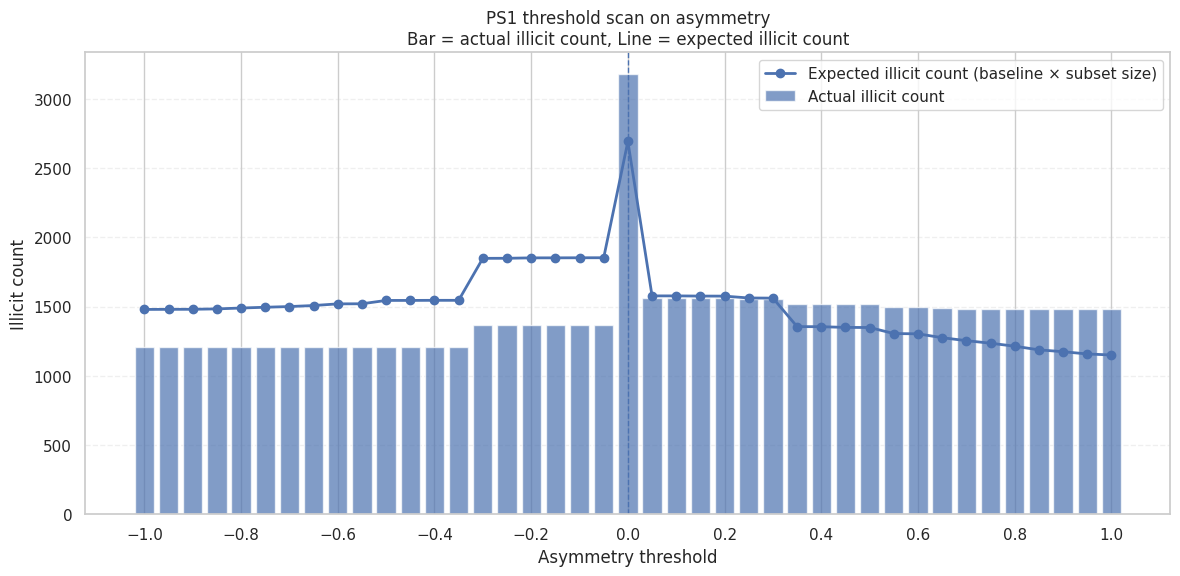

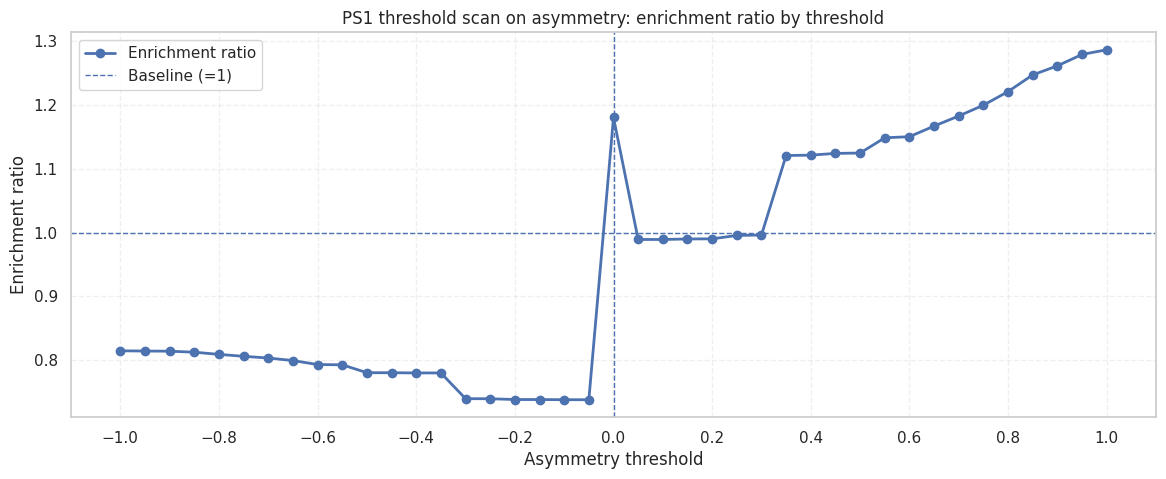


Top thresholds by enrichment ratio:


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015



Top thresholds by illicit count lift (actual - expected):


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) Baseline illicit rate trên toàn bộ labeled data =====
labeled_all = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

print(f"Baseline illicit rate = {baseline_illicit:.4f}")

# ===== 2) Hàm scan threshold =====
def scan_asymmetry_thresholds(
    df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=None
):
    if thresholds is None:
        thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)

    results = []

    for t in thresholds:
        # Quy tắc cắt:
        # t < 0  -> lấy phía trái: asymmetry <= t
        # t >= 0 -> lấy phía phải: asymmetry >= t
        if t < 0:
            subset = df[df[metric_col] <= t].copy()
            side = "left (distributor side)"
            rule = f"{metric_col} <= {t:.2f}"
        else:
            subset = df[df[metric_col] >= t].copy()
            side = "right (accumulator side)"
            rule = f"{metric_col} >= {t:.2f}"

        labeled_subset = subset[subset[class_col].isin(["licit", "illicit"])].copy()
        n_labeled = len(labeled_subset)

        actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
        illicit_rate_subset = (
            actual_illicit_count / n_labeled if n_labeled > 0 else np.nan
        )

        expected_illicit_count = (
            baseline_illicit * n_labeled if n_labeled > 0 else np.nan
        )

        enrichment_ratio = (
            illicit_rate_subset / baseline_illicit
            if (n_labeled > 0 and baseline_illicit > 0)
            else np.nan
        )

        lift_count = (
            actual_illicit_count - expected_illicit_count
            if n_labeled > 0 else np.nan
        )

        results.append({
            "threshold": t,
            "side": side,
            "rule": rule,
            "n_subset_total": len(subset),
            "n_subset_labeled": n_labeled,
            "actual_illicit_count": actual_illicit_count,
            "expected_illicit_count": expected_illicit_count,
            "illicit_rate_subset": illicit_rate_subset,
            "baseline_illicit_rate": baseline_illicit,
            "enrichment_ratio": enrichment_ratio,
            "lift_count": lift_count
        })

    return pd.DataFrame(results)

# ===== 3) Chạy scan =====
thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)
scan_df = scan_asymmetry_thresholds(
    ps1_df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=thresholds
)

display(scan_df.head(10))
display(scan_df.tail(10))

# ===== 4) Vẽ combo chart: Bar = illicit thực, Line = illicit kỳ vọng =====
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    scan_df["threshold"],
    scan_df["actual_illicit_count"],
    width=0.04,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    scan_df["threshold"],
    scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count (baseline × subset size)"
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Illicit count")
ax.set_title("PS1 threshold scan on asymmetry\nBar = actual illicit count, Line = expected illicit count")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# ===== 5) Thêm chart phụ để chọn threshold dễ hơn: enrichment ratio =====
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    scan_df["threshold"],
    scan_df["enrichment_ratio"],
    marker="o",
    linewidth=2,
    label="Enrichment ratio"
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Enrichment ratio")
ax.set_title("PS1 threshold scan on asymmetry: enrichment ratio by threshold")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# ===== 6) Gợi ý threshold 'tốt' theo vài tiêu chí =====
# (A) enrichment cao nhất nhưng yêu cầu có đủ mẫu labeled
min_labeled = 30
best_enrichment = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["enrichment_ratio", "actual_illicit_count"], ascending=[False, False])
    .head(10)
)

# (B) lift_count cao nhất: số illicit thực vượt kỳ vọng nhiều nhất
best_lift = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["lift_count", "enrichment_ratio"], ascending=[False, False])
    .head(10)
)

print("\nTop thresholds by enrichment ratio:")
display(best_enrichment)

print("\nTop thresholds by illicit count lift (actual - expected):")
display(best_lift)

# **Step 10 — Visualization**

**10.1 Histogram of asymmetry by class**

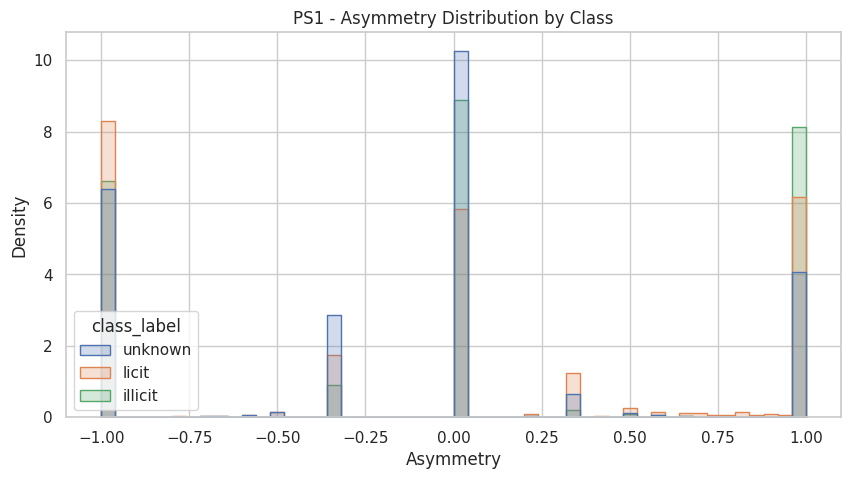

In [52]:
plot_df = ps1_df[ps1_df["class_label"].isin(["licit", "illicit", "unknown"])].copy()

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x="asymmetry",
    hue="class_label",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.title("PS1 - Asymmetry Distribution by Class")
plt.xlabel("Asymmetry")
plt.ylabel("Density")
plt.show()

**10.3 Scatter plot: in-degree vs out-degree**

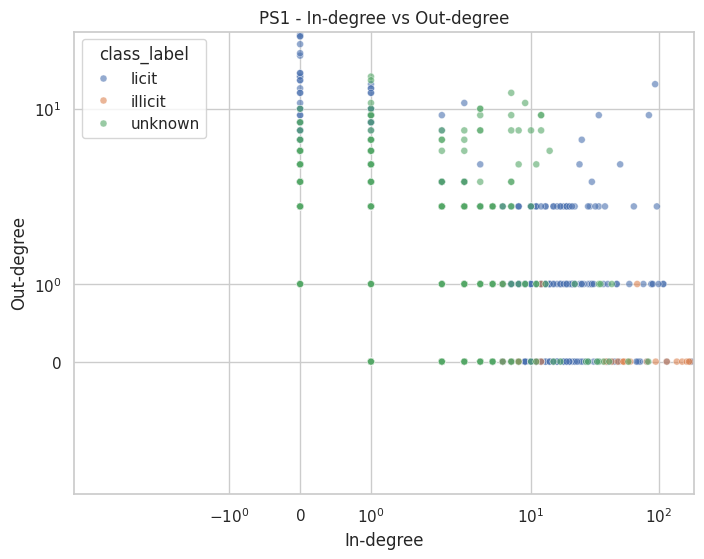

In [53]:
scatter_df = plot_df.copy()

# sample để plot đỡ nặng
sample_sizes = {
    "licit": 5000,
    "illicit": 3000,
    "unknown": 5000
}

scatter_sample = []
for cls, n in sample_sizes.items():
    temp = scatter_df[scatter_df["class_label"] == cls]
    scatter_sample.append(temp.sample(min(len(temp), n), random_state=42))

scatter_sample = pd.concat(scatter_sample, axis=0)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_sample,
    x="in_degree",
    y="out_degree",
    hue="class_label",
    alpha=0.6,
    s=25
)
plt.title("PS1 - In-degree vs Out-degree")
plt.xlabel("In-degree")
plt.ylabel("Out-degree")
plt.xscale("symlog")
plt.yscale("symlog")
plt.show()

# **Step 11 — Top extreme asymmetry nodes**

In [54]:
top_extreme = ps1_df.sort_values("abs_asymmetry", ascending=False).head(20)
display(top_extreme[[
    "txId", "time_step", "class_label", "in_degree", "out_degree",
    "total_degree", "asymmetry", "abs_asymmetry"
]])

,txId,time_step,class_label,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry
203768,157597225,49,unknown,1,0,1,1.0,1.0
203767,158654197,49,unknown,1,0,1,1.0,1.0
203766,158375402,49,illicit,0,1,1,-1.0,1.0
203765,158577750,49,unknown,1,0,1,1.0,1.0
203764,173077460,49,unknown,1,0,1,1.0,1.0
203748,164811301,49,unknown,0,1,1,-1.0,1.0
203747,161198026,49,unknown,0,1,1,-1.0,1.0
203746,158381551,49,unknown,0,1,1,-1.0,1.0
203745,157859979,49,unknown,1,0,1,1.0,1.0
203744,157617757,49,unknown,0,1,1,-1.0,1.0


# **Step 12 — Robustness check: compare all 3 groups directly**

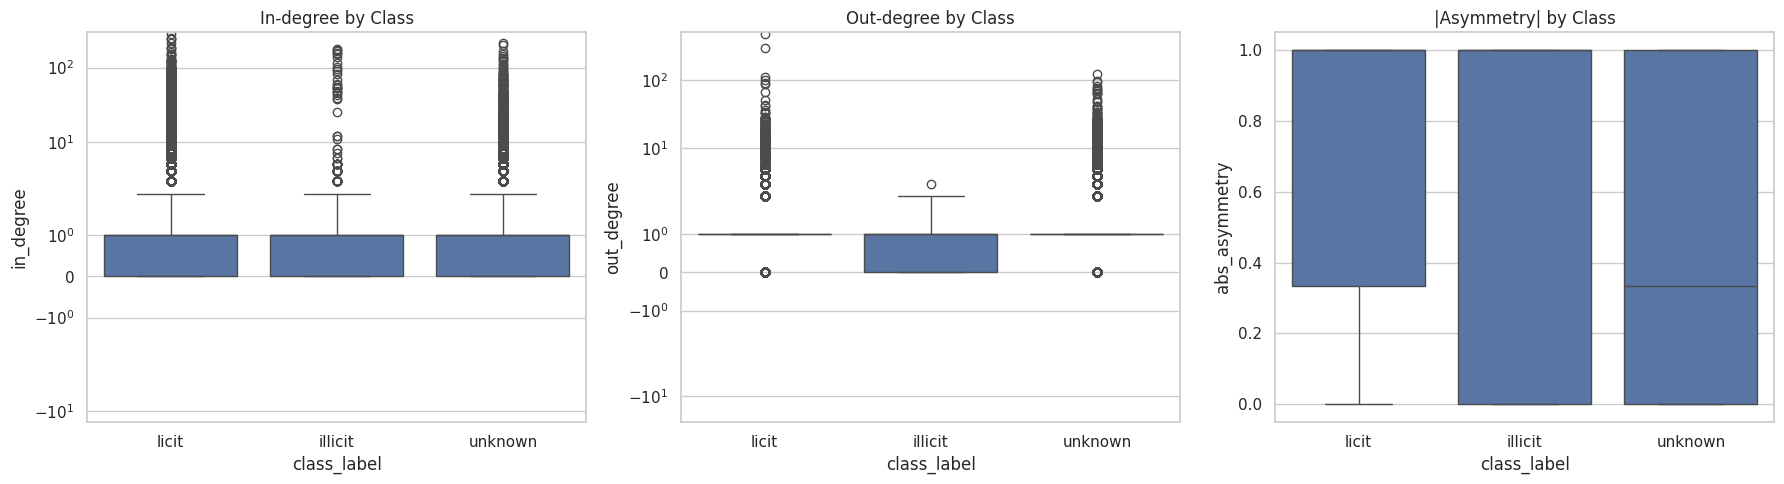

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=plot_df, x="class_label", y="in_degree", order=["licit", "illicit", "unknown"], ax=axes[0])
axes[0].set_title("In-degree by Class")
axes[0].set_yscale("symlog")

sns.boxplot(data=plot_df, x="class_label", y="out_degree", order=["licit", "illicit", "unknown"], ax=axes[1])
axes[1].set_title("Out-degree by Class")
axes[1].set_yscale("symlog")

sns.boxplot(data=plot_df, x="class_label", y="abs_asymmetry", order=["licit", "illicit", "unknown"], ax=axes[2])
axes[2].set_title("|Asymmetry| by Class")

plt.tight_layout()
plt.show()

# **Step 13 — PS1 summary table (để viết findings)**

In [56]:
summary_table = ps1_df.groupby("class_label")[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].median().reset_index()
display(summary_table)

display(mw_results)
display(enrichment_df)

,class_label,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry
0,illicit,1.0,1.0,1.0,0.0,1.000000
1,licit,1.0,1.0,2.0,0.0,1.000000
2,unknown,1.0,1.0,2.0,0.0,0.333333


,metric,n_licit,n_illicit,median_licit,median_illicit,u_stat,p_value,rank_biserial_corr
0,in_degree,42019,4545,1.0,1.0,100682787.5,5.552428e-11,-0.054401
1,out_degree,42019,4545,1.0,1.0,113640517.5,1.441678e-118,-0.190100
2,total_degree,42019,4545,2.0,1.0,119280225.5,6.844822e-188,-0.249162
3,asymmetry,42019,4545,0.0,0.0,86621821.5,1.628183e-26,0.092853
4,abs_asymmetry,42019,4545,1.0,1.0,99639397.0,5.797299e-08,-0.043474


,rule,n_subset_labeled,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio
0,asymmetry > 0.95,11861,0.124863,0.097608,1.279234
1,asymmetry > 0.5,13372,0.112100,0.097608,1.148475
2,asymmetry < -0.5,15575,0.077368,0.097608,0.792639


# ***PS2***

# **Step 1 — PS2 settings**

In [57]:
# =========================
# PS2 - SETTINGS
# =========================
BETWEENNESS_K = 1000
BETWEENNESS_SEED = 42
TOP_PCTS = [0.01, 0.05, 0.10]

print(f"Approximate betweenness with k = {BETWEENNESS_K}")

Approximate betweenness with k = 1000


# **Step 2 — Compute approximate betweenness (label-free)**

In [58]:
# =========================
# PS2 - APPROXIMATE BETWEENNESS
# =========================
betweenness_dict = nx.betweenness_centrality(
    G,
    k=min(BETWEENNESS_K, G.number_of_nodes()),
    normalized=True,
    seed=BETWEENNESS_SEED
)

betweenness_df = pd.DataFrame({
    "txId": list(betweenness_dict.keys()),
    "betweenness": list(betweenness_dict.values())
})

betweenness_df.head()

,txId,betweenness
0,230425980,0.000000e+00
1,5530458,0.000000e+00
2,232022460,0.000000e+00
3,232438397,2.453783e-08
4,230460314,0.000000e+00


# **Step 3 — Compute harmonic closeness (label-free)**

In [59]:
# =========================
# PS2 - HARMONIC CLOSENESS
# =========================
harmonic_dict = nx.harmonic_centrality(G)

harmonic_df = pd.DataFrame({
    "txId": list(harmonic_dict.keys()),
    "harmonic_closeness": list(harmonic_dict.values())
})

harmonic_df.head()

,txId,harmonic_closeness
0,272105479,0.000000
1,395313180,2.083333
2,339738664,3.961654
3,4718635,1.000000
4,48234540,0.000000


Harmonic closeness  đo một node gần các node khác đến mức nào, dựa trên tổng nghịch đảo khoảng cách shortest path.

# **Step 4 — Merge PS2 metrics into PS1 dataframe**

In [60]:
# =========================
# PS2 - MERGE METRICS
# =========================
ps2_metrics_df = betweenness_df.merge(harmonic_df, on="txId", how="inner")

ps2_df = ps1_df.merge(ps2_metrics_df, on="txId", how="left")

print(ps2_df.shape)
display(ps2_df[["txId", "betweenness", "harmonic_closeness"]].head())

(203769, 10)


,txId,betweenness,harmonic_closeness
0,230425980,0.000000e+00,2.592857
1,5530458,0.000000e+00,2.717857
2,232022460,0.000000e+00,1.833333
3,232438397,2.453783e-08,271.798424
4,230460314,0.000000e+00,2.500000


# **Step 5 — Global PS2 statistics (label-free)**

In [61]:
display(ps2_df[["betweenness", "harmonic_closeness"]].describe())

print("Non-zero betweenness fraction:", (ps2_df["betweenness"] > 0).mean().round(4))
print("Non-zero harmonic closeness fraction:", (ps2_df["harmonic_closeness"] > 0).mean().round(4))

,betweenness,harmonic_closeness
count,2.037690e+05,203769.000000
mean,4.013715e-08,3.192921
std,2.847633e-07,9.641385
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,1.500000
75%,0.000000e+00,3.439553
max,6.021583e-06,609.277058


Non-zero betweenness fraction: 0.0624
Non-zero harmonic closeness fraction: 0.7285


- chỉ ~6% node có betweenness > 0 => 94% node KHÔNG nằm trên shortest path của ai

- ~73% node có closeness > 0

# **Step 6 — Group statistics by class**

In [62]:
# =========================
# PS2 - GROUP STATS BY CLASS
# =========================
ps2_group_stats = ps2_df.groupby("class_label")[["betweenness", "harmonic_closeness"]].agg(
    ["count", "mean", "median", "std"]
)

display(ps2_group_stats)

betweenness                                    harmonic_closeness  \
                  count          mean median           std              count   
class_label                                                                     
illicit            4545  3.347295e-11    0.0  6.125316e-10               4545   
licit             42019  2.291157e-09    0.0  3.042961e-08              42019   
unknown          157205  5.141238e-08    0.0  3.229631e-07             157205   

                                            
                 mean    median        std  
class_label                                 
illicit      2.293839  1.000000   9.075538  
licit        4.304558  1.500000  15.841096  
unknown      2.921788  1.833333   7.114068

Illicit có betweenness THẤP NHẤT
illicit << licit << unknown

👉 Nghĩa là:

Illicit không phải bridge nodes

Illicit có closeness THẤP NHẤT

👉 Diễn giải:

illicit node:
xa network hơn
ít reachable nodes hơn

# **Helper function chung để tính enrichment theo subset**

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def enrichment_ratio(df_subset, class_col="class_label", positive_label="illicit", baseline=0.0):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

# **Baseline illicit rate**

In [64]:
labeled_all = ps2_df[ps2_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

print("Baseline illicit rate:", round(baseline_illicit, 6))

Baseline illicit rate: 0.097608


# **Scan threshold cho harmonic_closeness**

In [65]:
def scan_metric_thresholds(
    df,
    metric_col,
    thresholds,
    direction="ge",   # "ge" = >= threshold, "le" = <= threshold
    class_col="class_label",
    positive_label="illicit",
    baseline=0.0
):
    results = []

    for t in thresholds:
        if direction == "ge":
            subset = df[df[metric_col] >= t].copy()
            rule = f"{metric_col} >= {t:.6f}"
        elif direction == "le":
            subset = df[df[metric_col] <= t].copy()
            rule = f"{metric_col} <= {t:.6f}"
        else:
            raise ValueError("direction must be 'ge' or 'le'")

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["threshold"] = t
        stats["rule"] = rule
        stats["direction"] = direction
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)

        results.append(stats)

    return pd.DataFrame(results)

harmonic_nonnull = ps2_df["harmonic_closeness"].dropna()

harmonic_thresholds = sorted(harmonic_nonnull.quantile(
    [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
).unique())

harmonic_scan_df = scan_metric_thresholds(
    ps2_df,
    metric_col="harmonic_closeness",
    thresholds=harmonic_thresholds,
    direction="ge",
    class_col="class_label",
    positive_label="illicit",
    baseline=baseline_illicit
)

display(harmonic_scan_df)

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,threshold,rule,direction,metric,n_subset_total
0,23370,2214,2281.089468,0.094737,0.097608,0.970589,-67.089468,1.500000,harmonic_closeness >= 1.500000,ge,harmonic_closeness,117552
1,15958,1023,1557.621983,0.064106,0.097608,0.656770,-534.621983,2.083333,harmonic_closeness >= 2.083333,ge,harmonic_closeness,82107
2,12309,658,1201.451873,0.053457,0.097608,0.547671,-543.451873,2.928968,harmonic_closeness >= 2.928968,ge,harmonic_closeness,61554
3,10258,550,1001.258698,0.053617,0.097608,0.549309,-451.258698,3.439553,harmonic_closeness >= 3.439553,ge,harmonic_closeness,50970
4,8540,457,833.568851,0.053513,0.097608,0.548245,-376.568851,3.927171,harmonic_closeness >= 3.927171,ge,harmonic_closeness,40767
5,6884,356,671.930676,0.051714,0.097608,0.529817,-315.930676,4.575430,harmonic_closeness >= 4.575430,ge,harmonic_closeness,30581
6,5487,184,535.572867,0.033534,0.097608,0.343557,-351.572867,5.508088,harmonic_closeness >= 5.508088,ge,harmonic_closeness,20383
7,3989,105,389.356692,0.026322,0.097608,0.269676,-284.356692,7.820027,harmonic_closeness >= 7.820027,ge,harmonic_closeness,10189
8,2465,61,240.602719,0.024746,0.097608,0.253530,-179.602719,13.000000,harmonic_closeness >= 13.000000,ge,harmonic_closeness,6125
9,888,30,86.675543,0.033784,0.097608,0.346118,-56.675543,34.574372,harmonic_closeness >= 34.574372,ge,harmonic_closeness,2038


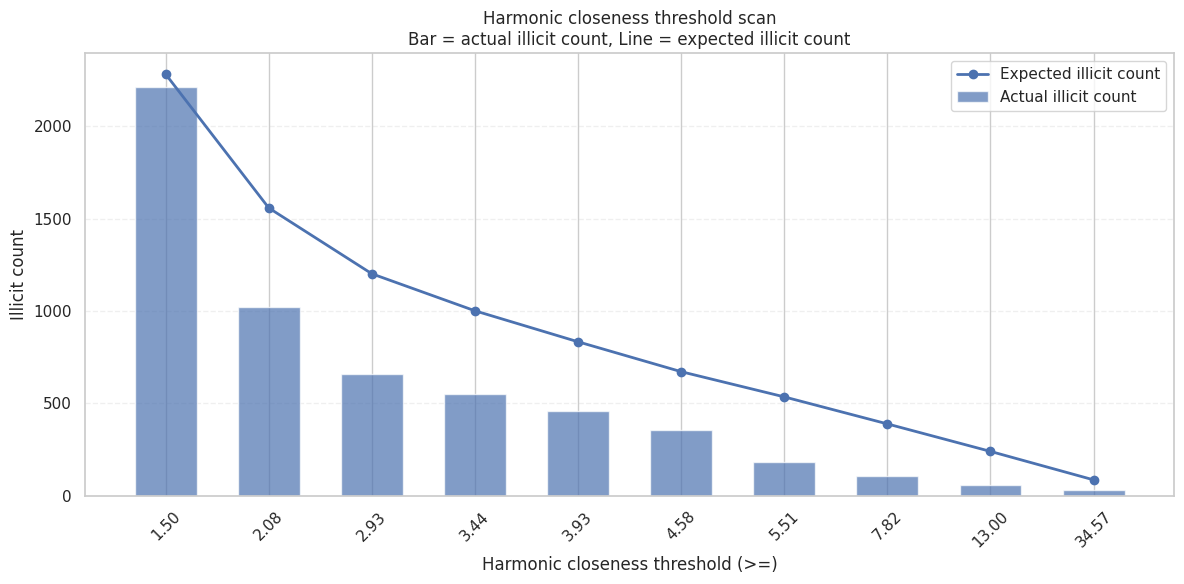

In [66]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(harmonic_scan_df))

ax.bar(
    x,
    harmonic_scan_df["actual_illicit_count"],
    width=0.6,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    x,
    harmonic_scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count"
)

ax.set_xticks(list(x))
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_df["threshold"]], rotation=45)
ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness threshold scan\nBar = actual illicit count, Line = expected illicit count")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Test cho harmo < thredshold

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Baseline =====
labeled_all = ps2_df[ps2_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

print("Baseline illicit rate:", round(baseline_illicit, 6))


# ===== Scan function (<= threshold) =====
def scan_harmonic_low(ps2_df, thresholds, baseline):
    results = []

    for t in thresholds:
        subset = ps2_df[ps2_df["harmonic_closeness"] <= t].copy()

        labeled_subset = subset[subset["class_label"].isin(["licit", "illicit"])]

        n_labeled = len(labeled_subset)

        if n_labeled == 0:
            continue

        actual_illicit = (labeled_subset["class_label"] == "illicit").sum()
        illicit_rate = actual_illicit / n_labeled
        expected_illicit = baseline * n_labeled
        enrichment = illicit_rate / baseline
        lift = actual_illicit - expected_illicit

        results.append({
            "threshold": t,
            "rule": f"harmonic_closeness <= {t:.6f}",
            "n_subset_total": len(subset),
            "n_subset_labeled": n_labeled,
            "actual_illicit_count": actual_illicit,
            "expected_illicit_count": expected_illicit,
            "illicit_rate_subset": illicit_rate,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": enrichment,
            "lift_count": lift
        })

    return pd.DataFrame(results)

harmonic_vals = ps2_df["harmonic_closeness"].dropna()

thresholds = sorted(harmonic_vals.quantile(
    [0.01, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
).unique())

harmonic_low_df = scan_harmonic_low(ps2_df, thresholds, baseline_illicit)

display(harmonic_low_df)

Baseline illicit rate: 0.097608


,threshold,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,0.0,harmonic_closeness <= 0.000000,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692
1,1.0,harmonic_closeness <= 1.000000,86217,23194,2331,2263.910532,0.100500,0.097608,1.029634,67.089468
2,1.5,harmonic_closeness <= 1.500000,103327,26827,3003,2618.518920,0.111939,0.097608,1.146832,384.481080


# CHART 

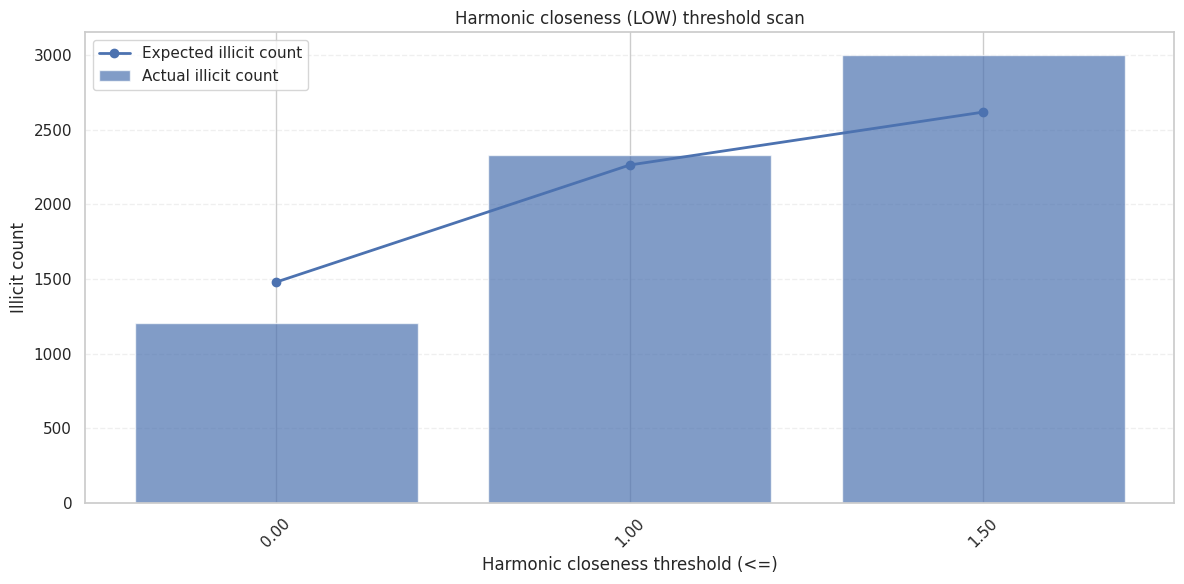

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(harmonic_low_df))

ax.bar(
    x,
    harmonic_low_df["actual_illicit_count"],
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    x,
    harmonic_low_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count"
)

ax.set_xticks(list(x))
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_low_df["threshold"]], rotation=45)

ax.set_xlabel("Harmonic closeness threshold (<=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness (LOW) threshold scan")

ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

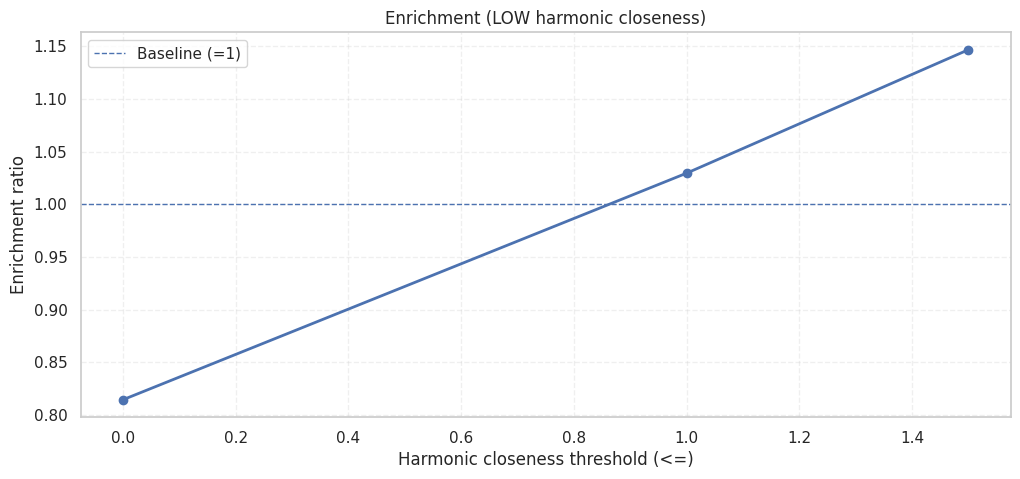

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    harmonic_low_df["threshold"],
    harmonic_low_df["enrichment_ratio"],
    marker="o",
    linewidth=2
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")

ax.set_xlabel("Harmonic closeness threshold (<=)")
ax.set_ylabel("Enrichment ratio")
ax.set_title("Enrichment (LOW harmonic closeness)")

ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [70]:
best = harmonic_low_df.sort_values(
    ["enrichment_ratio", "lift_count"],
    ascending=[False, False]
)

display(best.head(10))

,threshold,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
2,1.5,harmonic_closeness <= 1.500000,103327,26827,3003,2618.518920,0.111939,0.097608,1.146832,384.481080
1,1.0,harmonic_closeness <= 1.000000,86217,23194,2331,2263.910532,0.100500,0.097608,1.029634,67.089468
0,0.0,harmonic_closeness <= 0.000000,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692


In [71]:
subset_strong = ps2_df[
    (ps2_df["asymmetry"] > 0.8) &
    (ps2_df["harmonic_closeness"] <= 3)
]

res = enrichment_ratio(
    subset,
    class_col="class_label",
    positive_label="illicit",
    baseline=baseline_illicit
)

result_df = pd.DataFrame([res])
display(result_df)

NameError: name 'subset' is not defined

In [ ]:
subset_asym = ps2_df[ps2_df["asymmetry"] > 0.8]
subset_harm = ps2_df[ps2_df["harmonic_closeness"] <= 3]

res_asym = enrichment_ratio(subset_asym, baseline=baseline_illicit)
res_harm = enrichment_ratio(subset_harm, baseline=baseline_illicit)
res_comb = enrichment_ratio(subset, baseline=baseline_illicit)

compare_df = pd.DataFrame([
    {"rule": "asymmetry > 0.8", **res_asym},
    {"rule": "harmonic <= 3", **res_harm},
    {"rule": "combined", **res_comb}
])

display(compare_df)

# **Scan cho betweenness theo top %**

In [ ]:
def scan_top_percent(
    df,
    metric_col,
    top_pcts,
    class_col="class_label",
    positive_label="illicit",
    baseline=0.0
):
    results = []

    metric_series = df[metric_col].dropna()

    for p in top_pcts:
        cutoff = metric_series.quantile(1 - p)
        subset = df[df[metric_col] >= cutoff].copy()

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["top_pct"] = p
        stats["cutoff"] = cutoff
        stats["rule"] = f"{metric_col} >= Q{100*(1-p):.1f} cutoff"
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)

        results.append(stats)

    return pd.DataFrame(results)

top_pcts = [0.10, 0.05, 0.02, 0.01, 0.005]

betweenness_scan_df = scan_top_percent(
    ps2_df,
    metric_col="betweenness",
    top_pcts=top_pcts,
    class_col="class_label",
    positive_label="illicit",
    baseline=baseline_illicit
)

display(betweenness_scan_df)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(betweenness_scan_df))

ax.bar(
    x,
    betweenness_scan_df["actual_illicit_count"],
    width=0.6,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    x,
    betweenness_scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count"
)

ax.set_xticks(list(x))
ax.set_xticklabels([f"Top {p*100:.1f}%" for p in betweenness_scan_df["top_pct"]], rotation=0)
ax.set_xlabel("Betweenness top-percentage subset")
ax.set_ylabel("Illicit count")
ax.set_title("Betweenness top-percent scan\nBar = actual illicit count, Line = expected illicit count")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# **Step 7 — Mann–Whitney U test + rank-biserial correlation**

In [ ]:
# =========================
# PS2 - MANN-WHITNEY TEST
# =========================
ps2_metrics_to_test = ["betweenness", "harmonic_closeness"]

mw_ps2_results = pd.DataFrame([mannwhitney_test(ps2_df, m) for m in ps2_metrics_to_test])
display(mw_ps2_results)

Illicit có centrality thấp hơn licit

# **Step 8 — Betweenness percentile**

In [ ]:
# =========================
# PS2 - PERCENTILES
# =========================
ps2_df["betweenness_pct_rank"] = ps2_df["betweenness"].rank(pct=True, method="average")
ps2_df["harmonic_pct_rank"] = ps2_df["harmonic_closeness"].rank(pct=True, method="average")

display(
    ps2_df[["betweenness", "betweenness_pct_rank", "harmonic_closeness", "harmonic_pct_rank"]].head()
)

# **Step 9 — Enrichment analysis for top betweenness nodes**

In [ ]:
# =========================
# PS2 - ENRICHMENT: TOP BETW
# =========================
labeled_ps2_df = ps2_df[ps2_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit_ps2 = (labeled_ps2_df["class_label"] == "illicit").mean()

print(f"Baseline illicit rate (labeled only): {baseline_illicit_ps2:.4f}")

ps2_enrichment_results = []

for pct in TOP_PCTS:
    threshold = ps2_df["betweenness"].quantile(1 - pct)
    subset = ps2_df[ps2_df["betweenness"] >= threshold].copy()
    
    res = enrichment_ratio(subset, baseline=baseline_illicit_ps2)
    res["rule"] = f"top_{int(pct*100)}pct_betweenness"
    res["threshold"] = threshold
    ps2_enrichment_results.append(res)

ps2_enrichment_df = pd.DataFrame(ps2_enrichment_results)[[
    "rule", "threshold", "n_subset_labeled", "illicit_rate_subset",
    "baseline_illicit_rate", "enrichment_ratio"
]]

display(ps2_enrichment_df)

# **PS3**

# **Step 1 — PS3 settings**

In [86]:
# =========================
# PS3 - STEP 1
# SETTINGS
# =========================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, skew

TX_COL = "txId"
CLASS_COL = "class_label"
TIME_COL = "time_step"

PS3_BETWEENNESS_K = 1000
PS3_PAGERANK_ALPHA = 0.85
PS3_OUTLIER_Z = 2.0
PS3_TIMESTEP_ANOMALY_Z = 2.0
PS3_EXTREME_ASYM = 0.7

print("PS3 settings loaded.")

PS3 settings loaded.


# **Step 2 — Attach time_step vào dataframe hiện tại**

In [87]:
# =========================
# PS3 - STEP 2
# ATTACH / CLEAN TIME STEP
# =========================

time_map_df = df_features.iloc[:, [0, 1]].copy()
time_map_df.columns = [TX_COL, TIME_COL]

cols_to_drop = [c for c in ps2_df.columns if c in [TIME_COL, f"{TIME_COL}_x", f"{TIME_COL}_y"]]
ps2_df_clean = ps2_df.drop(columns=cols_to_drop, errors="ignore").copy()

ps3_df = ps2_df_clean.merge(time_map_df, on=TX_COL, how="left")

if TIME_COL not in ps3_df.columns:
    if f"{TIME_COL}_x" in ps3_df.columns:
        ps3_df[TIME_COL] = ps3_df[f"{TIME_COL}_x"]
    elif f"{TIME_COL}_y" in ps3_df.columns:
        ps3_df[TIME_COL] = ps3_df[f"{TIME_COL}_y"]

print("Shape:", ps3_df.shape)
print("Columns containing 'time':", [c for c in ps3_df.columns if "time" in str(c).lower()])
display(ps3_df[[TX_COL, CLASS_COL, TIME_COL]].head())
print("Number of timesteps:", ps3_df[TIME_COL].nunique())
print("Sample timesteps:", sorted(ps3_df[TIME_COL].dropna().unique())[:10])
print("Missing time_step:", ps3_df[TIME_COL].isna().sum())

Shape: (203769, 10)
Columns containing 'time': ['time_step']


,txId,class_label,time_step
0,230425980,unknown,1
1,5530458,unknown,1
2,232022460,unknown,1
3,232438397,licit,1
4,230460314,unknown,1


Number of timesteps: 49
Sample timesteps: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Missing time_step: 0


# **Step 3 — Build 49 timestep snapshots**

In [89]:
# =========================
# PS3 - STEP 3
# BUILD TIMESTEP SNAPSHOTS
# =========================

edges_ps3 = df_edges[["txId1", "txId2"]].rename(
    columns={"txId1": "src", "txId2": "dst"}
).copy()

node_time = ps3_df.set_index(TX_COL)[TIME_COL].to_dict()
valid_nodes = set(ps3_df[TX_COL])

edges_ps3 = edges_ps3[
    edges_ps3["src"].isin(valid_nodes) &
    edges_ps3["dst"].isin(valid_nodes)
].copy()

edges_ps3["src_t"] = edges_ps3["src"].map(node_time)
edges_ps3["dst_t"] = edges_ps3["dst"].map(node_time)

# Giữ edge nội bộ cùng timestep
intra_edges = edges_ps3[edges_ps3["src_t"] == edges_ps3["dst_t"]].copy()

print("All edges:", len(edges_ps3))
print("Intra-timestep edges:", len(intra_edges))
display(intra_edges.head())

snapshot_stats = []
all_timesteps = sorted(ps3_df[TIME_COL].dropna().unique())

for t in all_timesteps:
    nodes_t = ps3_df.loc[ps3_df[TIME_COL] == t, TX_COL].tolist()
    edges_t = intra_edges.loc[intra_edges["src_t"] == t, ["src", "dst"]]

    G_t = nx.DiGraph()
    G_t.add_nodes_from(nodes_t)
    G_t.add_edges_from(edges_t.itertuples(index=False, name=None))

    n_nodes = G_t.number_of_nodes()
    n_edges = G_t.number_of_edges()
    density = nx.density(G_t) if n_nodes > 1 else 0.0
    n_wcc = nx.number_weakly_connected_components(G_t) if n_nodes > 0 else 0

    snapshot_stats.append({
        "time_step": t,
        "n_nodes_t": n_nodes,
        "n_edges_t": n_edges,
        "density_t": density,
        "n_wcc_t": n_wcc
    })

snapshot_df = pd.DataFrame(snapshot_stats)

print("snapshot_df shape:", snapshot_df.shape)
display(snapshot_df.head())
display(snapshot_df.describe())

All edges: 234355
Intra-timestep edges: 234355


,src,dst,src_t,dst_t
0,230425980,5530458,1,1
1,232022460,232438397,1,1
2,230460314,230459870,1,1
3,230333930,230595899,1,1
4,232013274,232029206,1,1


snapshot_df shape: (49, 5)


,time_step,n_nodes_t,n_edges_t,density_t,n_wcc_t
0,1,7880,9164,0.000148,1
1,2,4544,5241,0.000254,1
2,3,6621,8316,0.000190,1
3,4,5693,8180,0.000252,1
4,5,6803,8623,0.000186,1


,time_step,n_nodes_t,n_edges_t,density_t,n_wcc_t
count,49.00000,49.000000,49.000000,49.000000,49.0
mean,25.00000,4158.551020,4782.755102,0.000318,1.0
std,14.28869,1592.470592,2081.940236,0.000146,0.0
min,1.00000,1089.000000,1168.000000,0.000148,1.0
25%,13.00000,2891.000000,3094.000000,0.000224,1.0
50%,25.00000,4291.000000,4656.000000,0.000261,1.0
75%,37.00000,5121.000000,5950.000000,0.000376,1.0
max,49.00000,7880.000000,9164.000000,0.000986,1.0


# **Step 4 — Node-level metrics within each timestep**

In [90]:
# =========================
# PS3 - STEP 4
# NODE-LEVEL METRICS WITHIN EACH TIMESTEP
# =========================

node_metric_rows = []

for t in all_timesteps:
    nodes_t = ps3_df.loc[ps3_df[TIME_COL] == t, TX_COL].tolist()
    edges_t = intra_edges.loc[intra_edges["src_t"] == t, ["src", "dst"]]

    G_t = nx.DiGraph()
    G_t.add_nodes_from(nodes_t)
    G_t.add_edges_from(edges_t.itertuples(index=False, name=None))

    in_deg = dict(G_t.in_degree())
    out_deg = dict(G_t.out_degree())
    total_deg = {n: in_deg[n] + out_deg[n] for n in G_t.nodes()}

    asym_t = {}
    abs_asym_t = {}
    for n in G_t.nodes():
        td = total_deg[n]
        a = (in_deg[n] - out_deg[n]) / td if td > 0 else 0.0
        asym_t[n] = a
        abs_asym_t[n] = abs(a)

    n_nodes = G_t.number_of_nodes()
    if n_nodes <= 1:
        btw_t = {n: 0.0 for n in G_t.nodes()}
        pr_t = {n: 0.0 for n in G_t.nodes()}
    else:
        k_t = min(PS3_BETWEENNESS_K, n_nodes)

        btw_t = nx.betweenness_centrality(
            G_t,
            k=k_t,
            normalized=True,
            seed=42
        )

        pr_t = nx.pagerank(G_t, alpha=PS3_PAGERANK_ALPHA)

    for n in G_t.nodes():
        node_metric_rows.append({
            TX_COL: n,
            "time_step": t,
            "in_degree_t": in_deg[n],
            "out_degree_t": out_deg[n],
            "total_degree_t": total_deg[n],
            "asymmetry_t": asym_t[n],
            "abs_asymmetry_t": abs_asym_t[n],
            "betweenness_t": btw_t[n],
            "pagerank_t": pr_t[n]
        })

ps3_node_metrics_df = pd.DataFrame(node_metric_rows)

print("ps3_node_metrics_df shape:", ps3_node_metrics_df.shape)
display(ps3_node_metrics_df.head())
display(ps3_node_metrics_df.describe())

ps3_node_metrics_df shape: (203769, 9)


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t
0,230425980,1,1,1,2,0.000000,0.000000,2.538715e-07,0.000105
1,5530458,1,1,1,2,0.000000,0.000000,1.269358e-07,0.000130
2,232022460,1,1,2,3,-0.333333,0.333333,0.000000e+00,0.000130
3,232438397,1,160,1,161,0.987578,0.987578,3.684822e-05,0.007200
4,230460314,1,2,8,10,-0.600000,0.600000,0.000000e+00,0.000055


,txId,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t
count,2.037690e+05,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000
mean,1.711310e+08,23.843961,1.150101,1.150101,2.300203,-0.108612,0.521818,0.000127,0.000240
std,1.104655e+08,15.172170,3.911132,1.894740,4.328377,0.687363,0.460401,0.000752,0.000463
min,1.076000e+03,1.000000,0.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000036
25%,8.433452e+07,9.000000,0.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,0.000086
50%,1.624375e+08,23.000000,1.000000,1.000000,2.000000,0.000000,0.333333,0.000000,0.000146
75%,2.454798e+08,38.000000,1.000000,1.000000,2.000000,0.000000,1.000000,0.000002,0.000264
max,4.032446e+08,49.000000,284.000000,472.000000,473.000000,1.000000,1.000000,0.008953,0.026554


# **Step 5 - Within-timestep z-scores**

In [91]:
# =========================
# PS3 - STEP 5
# WITHIN-TIMESTEP Z-SCORES
# =========================

def safe_group_zscore(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

ps3_node_metrics_df["z_betweenness_t"] = (
    ps3_node_metrics_df.groupby("time_step")["betweenness_t"]
    .transform(safe_group_zscore)
)

ps3_node_metrics_df["z_degree_t"] = (
    ps3_node_metrics_df.groupby("time_step")["total_degree_t"]
    .transform(safe_group_zscore)
)

ps3_node_metrics_df["z_abs_asymmetry_t"] = (
    ps3_node_metrics_df.groupby("time_step")["abs_asymmetry_t"]
    .transform(safe_group_zscore)
)

ps3_node_metrics_df["z_pagerank_t"] = (
    ps3_node_metrics_df.groupby("time_step")["pagerank_t"]
    .transform(safe_group_zscore)
)

print("ps3_node_metrics_df shape:", ps3_node_metrics_df.shape)

display(
    ps3_node_metrics_df[
        [
            TX_COL, "time_step",
            "betweenness_t", "z_betweenness_t",
            "total_degree_t", "z_degree_t",
            "abs_asymmetry_t", "z_abs_asymmetry_t",
            "pagerank_t", "z_pagerank_t"
        ]
    ].head()
)

display(
    ps3_node_metrics_df[
        ["z_betweenness_t", "z_degree_t", "z_abs_asymmetry_t", "z_pagerank_t"]
    ].describe()
)

ps3_node_metrics_df shape: (203769, 13)


,txId,time_step,betweenness_t,z_betweenness_t,total_degree_t,z_degree_t,abs_asymmetry_t,z_abs_asymmetry_t,pagerank_t,z_pagerank_t
0,230425980,1,2.538715e-07,-0.184938,2,-0.065959,0.000000,-1.023046,0.000105,-0.093730
1,5530458,1,1.269358e-07,-0.188825,2,-0.065959,0.000000,-1.023046,0.000130,0.014449
2,232022460,1,0.000000e+00,-0.192713,3,0.136438,0.333333,-0.270252,0.000130,0.012621
3,232438397,1,3.684822e-05,0.935841,161,32.115026,0.987578,1.207280,0.007200,30.618613
4,230460314,1,0.000000e+00,-0.192713,10,1.553211,0.600000,0.331982,0.000055,-0.313125


,z_betweenness_t,z_degree_t,z_abs_asymmetry_t,z_pagerank_t
count,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05
mean,-2.371161e-18,2.789601e-18,5.579202e-19,-5.300242e-18
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-8.546022e-01,-6.173964e-01,-1.488998e+00,-8.081142e-01
25%,-3.405229e-01,-2.683547e-01,-1.057442e+00,-3.345423e-01
50%,-2.510914e-01,-8.496111e-02,-1.685333e-01,-1.974074e-01
75%,-1.655200e-01,-3.302554e-02,9.743664e-01,8.665395e-02
max,3.655032e+01,6.480219e+01,1.594491e+00,5.109013e+01


# **Step 6 — Outlier flags within timestep**

In [96]:
# =========================
# PS3 - STEP 6
# OUTLIER FLAGS
# =========================

ps3_node_metrics_df["flag_betweenness_t"] = (
    ps3_node_metrics_df["z_betweenness_t"].abs() > PS3_OUTLIER_Z
).astype(int)

ps3_node_metrics_df["flag_degree_t"] = (
    ps3_node_metrics_df["z_degree_t"].abs() > PS3_OUTLIER_Z
).astype(int)

ps3_node_metrics_df["flag_abs_asymmetry_t"] = (
    ps3_node_metrics_df["z_abs_asymmetry_t"].abs() > PS3_OUTLIER_Z
).astype(int)

ps3_node_metrics_df["flag_pagerank_t"] = (
    ps3_node_metrics_df["z_pagerank_t"].abs() > PS3_OUTLIER_Z
).astype(int)

flag_cols = [
    "flag_betweenness_t",
    "flag_degree_t",
    "flag_abs_asymmetry_t",
    "flag_pagerank_t"
]

ps3_node_metrics_df["outlier_flag_count_t"] = ps3_node_metrics_df[flag_cols].sum(axis=1)
ps3_node_metrics_df["any_outlier_t"] = (ps3_node_metrics_df["outlier_flag_count_t"] > 0).astype(int)

print("Any outlier fraction:", round(ps3_node_metrics_df["any_outlier_t"].mean(), 4))

outlier_summary = pd.DataFrame({
    "metric": [
        "betweenness_t",
        "degree_t",
        "abs_asymmetry_t",
        "pagerank_t",
        "any_outlier_t"
    ],
    "outlier_count": [
        ps3_node_metrics_df["flag_betweenness_t"].sum(),
        ps3_node_metrics_df["flag_degree_t"].sum(),
        ps3_node_metrics_df["flag_abs_asymmetry_t"].sum(),
        ps3_node_metrics_df["flag_pagerank_t"].sum(),
        ps3_node_metrics_df["any_outlier_t"].sum()
    ]
})

outlier_summary["outlier_fraction"] = outlier_summary["outlier_count"] / len(ps3_node_metrics_df)

display(outlier_summary)

display(
    ps3_node_metrics_df[
        [TX_COL, "time_step"] + flag_cols + ["outlier_flag_count_t", "any_outlier_t"]
    ].head()
)

display(ps3_node_metrics_df["outlier_flag_count_t"].value_counts(dropna=False).sort_index())

Any outlier fraction: 0.066


,metric,outlier_count,outlier_fraction
0,betweenness_t,9248,0.045385
1,degree_t,2889,0.014178
2,abs_asymmetry_t,0,0.000000
3,pagerank_t,3116,0.015292
4,any_outlier_t,13454,0.066026


,txId,time_step,flag_betweenness_t,flag_degree_t,flag_abs_asymmetry_t,flag_pagerank_t,outlier_flag_count_t,any_outlier_t
0,230425980,1,0,0,0,0,0,0
1,5530458,1,0,0,0,0,0,0
2,232022460,1,0,0,0,0,0,0
3,232438397,1,0,1,0,1,2,1
4,230460314,1,0,0,0,0,0,0


outlier_flag_count_t
0    190315
1     11770
2      1569
3       115
Name: count, dtype: int64

# **Step 7 — Build timestep-level aggregate table**

In [97]:
# =========================
# PS3 - STEP 7
# TIMESTEP-LEVEL AGGREGATES
# =========================

agg_rows = []

for t, g in ps3_node_metrics_df.groupby("time_step"):
    agg_rows.append({
        "time_step": t,
        "n_nodes_t": len(g),

        "mean_betweenness_t": g["betweenness_t"].mean(),
        "median_betweenness_t": g["betweenness_t"].median(),
        "std_betweenness_t": g["betweenness_t"].std(),

        "mean_degree_t": g["total_degree_t"].mean(),
        "median_degree_t": g["total_degree_t"].median(),
        "std_degree_t": g["total_degree_t"].std(),

        "mean_abs_asymmetry_t": g["abs_asymmetry_t"].mean(),
        "median_abs_asymmetry_t": g["abs_asymmetry_t"].median(),
        "std_abs_asymmetry_t": g["abs_asymmetry_t"].std(),

        "mean_pagerank_t": g["pagerank_t"].mean(),
        "median_pagerank_t": g["pagerank_t"].median(),

        "degree_skew_t": skew(g["total_degree_t"], bias=False) if len(g) > 2 else np.nan,
        "extreme_asym_frac_t": (g["abs_asymmetry_t"] > PS3_EXTREME_ASYM).mean(),

        "n_outliers_t": g["any_outlier_t"].sum(),
        "outlier_frac_t": g["any_outlier_t"].mean()
    })

ps3_timestep_agg_df = pd.DataFrame(agg_rows).merge(
    snapshot_df,
    on="time_step",
    how="left"
)

print("ps3_timestep_agg_df shape:", ps3_timestep_agg_df.shape)
display(ps3_timestep_agg_df.head())
display(ps3_timestep_agg_df.describe())

ps3_timestep_agg_df shape: (49, 21)


,time_step,n_nodes_t_x,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_degree_t,median_degree_t,std_degree_t,mean_abs_asymmetry_t,median_abs_asymmetry_t,std_abs_asymmetry_t,mean_pagerank_t,median_pagerank_t,degree_skew_t,extreme_asym_frac_t,n_outliers_t,outlier_frac_t,n_nodes_t_y,n_edges_t,density_t,n_wcc_t
0,1,7880,0.000006,0.000000,0.000033,2.325888,2.0,4.941119,0.453000,0.333333,0.442823,0.000127,0.000085,37.105762,0.375000,285,0.036168,7880,9164,0.000148,1
1,2,4544,0.000040,0.000000,0.000126,2.306778,2.0,2.543409,0.524068,0.333333,0.451933,0.000220,0.000137,10.550242,0.457746,425,0.093530,4544,5241,0.000254,1
2,3,6621,0.001115,0.000002,0.002359,2.512007,2.0,2.449190,0.401717,0.333333,0.425724,0.000151,0.000105,6.319671,0.311131,1080,0.163117,6621,8316,0.000190,1
3,4,5693,0.000257,0.000000,0.000724,2.873705,2.0,4.971956,0.480602,0.333333,0.441748,0.000176,0.000110,23.568147,0.399614,532,0.093448,5693,8180,0.000252,1
4,5,6803,0.000007,0.000000,0.000020,2.535058,2.0,4.351614,0.491577,0.333333,0.443399,0.000147,0.000101,26.806668,0.415552,512,0.075261,6803,8623,0.000186,1


,time_step,n_nodes_t_x,mean_betweenness_t,median_betweenness_t,std_betweenness_t,mean_degree_t,median_degree_t,std_degree_t,mean_abs_asymmetry_t,median_abs_asymmetry_t,std_abs_asymmetry_t,mean_pagerank_t,median_pagerank_t,degree_skew_t,extreme_asym_frac_t,n_outliers_t,outlier_frac_t,n_nodes_t_y,n_edges_t,density_t,n_wcc_t
count,49.00000,49.000000,49.000000,49.000000,49.000000,49.000000,49.0,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.0
mean,25.00000,4158.551020,0.000115,0.000016,0.000216,2.257909,2.0,4.029446,0.530466,0.612925,0.456481,0.000287,0.000184,17.766133,0.478420,274.571429,0.067699,4158.551020,4782.755102,0.000318,1.0
std,14.28869,1592.470592,0.000388,0.000108,0.000534,0.155483,0.0,1.219099,0.076530,0.360222,0.011924,0.000144,0.000088,7.921613,0.083999,159.315332,0.024746,1592.470592,2081.940236,0.000146,0.0
min,1.00000,1089.000000,0.000002,0.000000,0.000007,2.055391,2.0,2.127259,0.336342,0.000000,0.416267,0.000127,0.000085,6.319671,0.262708,83.000000,0.028760,1089.000000,1168.000000,0.000148,1.0
25%,13.00000,2891.000000,0.000005,0.000000,0.000019,2.140688,2.0,3.128993,0.484669,0.333333,0.452592,0.000195,0.000117,12.809598,0.422419,178.000000,0.055249,2891.000000,3094.000000,0.000224,1.0
50%,25.00000,4291.000000,0.000016,0.000000,0.000050,2.223426,2.0,4.041945,0.537115,0.500000,0.457628,0.000233,0.000155,16.376883,0.486633,254.000000,0.064153,4291.000000,4656.000000,0.000261,1.0
75%,37.00000,5121.000000,0.000041,0.000000,0.000138,2.341442,2.0,4.784105,0.590748,1.000000,0.463319,0.000346,0.000213,20.544699,0.540498,308.000000,0.079742,5121.000000,5950.000000,0.000376,1.0
max,49.00000,7880.000000,0.002525,0.000758,0.002955,2.873705,2.0,7.263024,0.657196,1.000000,0.473775,0.000918,0.000547,48.950110,0.614379,1080.000000,0.163117,7880.000000,9164.000000,0.000986,1.0


# **Step 8 — Detect anomalous timesteps**

In [99]:
# =========================
# PS3 - STEP 8
# TIMESTEP ANOMALY DETECTION
# =========================

timestep_features_for_anomaly = [
    "mean_betweenness_t",
    "mean_degree_t",
    "mean_abs_asymmetry_t",
    "degree_skew_t",
    "extreme_asym_frac_t",
    "outlier_frac_t"
]

for col in timestep_features_for_anomaly:
    ps3_timestep_agg_df[f"z_{col}"] = safe_group_zscore(ps3_timestep_agg_df[col])

z_cols = [f"z_{c}" for c in timestep_features_for_anomaly]

ps3_timestep_agg_df["timestep_anomaly_score"] = ps3_timestep_agg_df[z_cols].abs().sum(axis=1)
ps3_timestep_agg_df["timestep_anomaly_flag"] = (
    ps3_timestep_agg_df[z_cols].abs().max(axis=1) > PS3_TIMESTEP_ANOMALY_Z
).astype(int)

display(
    ps3_timestep_agg_df[
        ["time_step", "timestep_anomaly_score", "timestep_anomaly_flag"] + z_cols
    ].sort_values("timestep_anomaly_score", ascending=False).head(10)
)

,time_step,timestep_anomaly_score,timestep_anomaly_flag,z_mean_betweenness_t,z_mean_degree_t,z_mean_abs_asymmetry_t,z_degree_skew_t,z_extreme_asym_frac_t,z_outlier_frac_t
5,6,14.924813,1,6.268383,1.068676,-2.562857,0.958580,-2.594634,-1.471683
2,3,13.318696,1,2.599778,1.651184,-1.699770,-1.459940,-2.012188,3.895836
9,10,7.878459,1,0.193554,1.919466,-1.653480,1.988783,-2.010364,0.112812
3,4,7.768505,1,0.369410,4.001569,-0.658304,0.740018,-0.947903,1.051301
0,1,6.746513,1,-0.284000,0.441744,-1.022719,2.466675,-1.243960,-1.287414
32,33,6.498084,1,-0.002910,-0.789170,-2.072487,0.937940,-1.624256,1.071321
14,15,5.925061,0,0.085039,-1.018804,-1.879621,-0.719600,-1.586479,0.635520
45,46,5.754939,0,-0.291796,-0.394401,1.673113,0.214443,1.635344,-1.545842
21,22,5.566167,1,-0.242060,0.793682,0.087787,3.977364,-0.111851,-0.353425
13,14,5.049182,0,0.158869,-1.316006,-0.604617,-0.914514,-0.376941,1.678235


# **Step 9 — Merge labels only now**

In [100]:
# =========================
# PS3 - STEP 9
# MERGE LABELS FOR POST-HOC EVALUATION
# =========================

ps3_eval_df = ps3_df[[TX_COL, CLASS_COL, TIME_COL]].merge(
    ps3_node_metrics_df,
    on=[TX_COL, "time_step"],
    how="left"
).merge(
    ps3_timestep_agg_df[["time_step", "timestep_anomaly_score", "timestep_anomaly_flag"]],
    on="time_step",
    how="left"
)

print("ps3_eval_df shape:", ps3_eval_df.shape)
display(ps3_eval_df.head())

ps3_eval_df shape: (203769, 22)


,txId,class_label,time_step,in_degree_t,out_degree_t,total_degree_t,asymmetry_t,abs_asymmetry_t,betweenness_t,pagerank_t,z_betweenness_t,z_degree_t,z_abs_asymmetry_t,z_pagerank_t,flag_betweenness_t,flag_degree_t,flag_abs_asymmetry_t,flag_pagerank_t,outlier_flag_count_t,any_outlier_t,timestep_anomaly_score,timestep_anomaly_flag
0,230425980,unknown,1,1,1,2,0.000000,0.000000,2.538715e-07,0.000105,-0.184938,-0.065959,-1.023046,-0.093730,0,0,0,0,0,0,6.746513,1
1,5530458,unknown,1,1,1,2,0.000000,0.000000,1.269358e-07,0.000130,-0.188825,-0.065959,-1.023046,0.014449,0,0,0,0,0,0,6.746513,1
2,232022460,unknown,1,1,2,3,-0.333333,0.333333,0.000000e+00,0.000130,-0.192713,0.136438,-0.270252,0.012621,0,0,0,0,0,0,6.746513,1
3,232438397,licit,1,160,1,161,0.987578,0.987578,3.684822e-05,0.007200,0.935841,32.115026,1.207280,30.618613,0,1,0,1,2,1,6.746513,1
4,230460314,unknown,1,2,8,10,-0.600000,0.600000,0.000000e+00,0.000055,-0.192713,1.553211,0.331982,-0.313125,0,0,0,0,0,0,6.746513,1


# **Step 10 — Enrichment of within-timestep outliers**

In [102]:
# =========================
# PS3 - STEP 10
# WITHIN-TIMESTEP OUTLIER ENRICHMENT
# =========================

labeled_ps3 = ps3_eval_df[ps3_eval_df[CLASS_COL].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_ps3[CLASS_COL] == "illicit").mean()

print("Baseline illicit rate:", round(baseline_illicit, 6))

def enrichment_ratio(df_subset, class_col="class_label", positive_label="illicit", baseline=0.0):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

ps3_outlier_results = pd.DataFrame([
    {"rule": "any_outlier_t == 1", **enrichment_ratio(labeled_ps3[labeled_ps3["any_outlier_t"] == 1], baseline=baseline_illicit)},
    {"rule": "flag_betweenness_t == 1", **enrichment_ratio(labeled_ps3[labeled_ps3["flag_betweenness_t"] == 1], baseline=baseline_illicit)},
    {"rule": "flag_degree_t == 1", **enrichment_ratio(labeled_ps3[labeled_ps3["flag_degree_t"] == 1], baseline=baseline_illicit)},
    {"rule": "flag_abs_asymmetry_t == 1", **enrichment_ratio(labeled_ps3[labeled_ps3["flag_abs_asymmetry_t"] == 1], baseline=baseline_illicit)},
    {"rule": "flag_pagerank_t == 1", **enrichment_ratio(labeled_ps3[labeled_ps3["flag_pagerank_t"] == 1], baseline=baseline_illicit)},
    {"rule": "outlier_flag_count_t >= 2", **enrichment_ratio(labeled_ps3[labeled_ps3["outlier_flag_count_t"] >= 2], baseline=baseline_illicit)},
    {"rule": "outlier_flag_count_t >= 3", **enrichment_ratio(labeled_ps3[labeled_ps3["outlier_flag_count_t"] >= 3], baseline=baseline_illicit)},
])

display(ps3_outlier_results.sort_values("enrichment_ratio", ascending=False))

Baseline illicit rate: 0.097608


,rule,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
1,flag_betweenness_t == 1,880,231,85.894683,0.262500,0.097608,2.689340,145.105317
0,any_outlier_t == 1,2800,271,273.301263,0.096786,0.097608,0.991580,-2.301263
4,flag_pagerank_t == 1,1510,38,147.387467,0.025166,0.097608,0.257824,-109.387467
5,outlier_flag_count_t >= 2,1137,25,110.979834,0.021988,0.097608,0.225266,-85.979834
2,flag_degree_t == 1,1643,27,160.369277,0.016433,0.097608,0.168361,-133.369277
6,outlier_flag_count_t >= 3,96,0,9.370329,0.000000,0.097608,0.000000,-9.370329
3,flag_abs_asymmetry_t == 1,0,0,NaN,NaN,0.097608,NaN,NaN


# **Step 11 — Enrichment of anomalous timesteps**

In [103]:
# =========================
# PS3 - STEP 11
# ANOMALOUS TIMESTEP ENRICHMENT
# =========================

timestep_label_stats = (
    labeled_ps3.groupby("time_step")
    .apply(lambda g: pd.Series({
        "n_labeled_t": len(g),
        "illicit_count_t": (g[CLASS_COL] == "illicit").sum(),
        "illicit_frac_t": (g[CLASS_COL] == "illicit").mean()
    }))
    .reset_index()
)

ps3_timestep_eval_df = ps3_timestep_agg_df.merge(
    timestep_label_stats,
    on="time_step",
    how="left"
)

anom_steps = ps3_timestep_eval_df[ps3_timestep_eval_df["timestep_anomaly_flag"] == 1]
normal_steps = ps3_timestep_eval_df[ps3_timestep_eval_df["timestep_anomaly_flag"] == 0]

print("Mean illicit fraction - anomalous steps:", round(anom_steps["illicit_frac_t"].mean(), 4))
print("Mean illicit fraction - normal steps:", round(normal_steps["illicit_frac_t"].mean(), 4))

res_anom_steps = enrichment_ratio(
    labeled_ps3[labeled_ps3["time_step"].isin(anom_steps["time_step"])],
    baseline=baseline_illicit
)

display(pd.DataFrame([{"rule": "nodes in anomalous timesteps", **res_anom_steps}]))
display(ps3_timestep_eval_df[["time_step", "timestep_anomaly_score", "timestep_anomaly_flag", "illicit_frac_t"]])

Mean illicit fraction - anomalous steps: 0.0297
Mean illicit fraction - normal steps: 0.1274


,rule,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,nodes in anomalous timesteps,8527,262,832.299953,0.030726,0.097608,0.31479,-570.299953


,time_step,timestep_anomaly_score,timestep_anomaly_flag,illicit_frac_t
0,1,6.746513,1,0.007918
1,2,2.822103,0,0.016115
2,3,13.318696,1,0.008600
3,4,7.768505,1,0.020833
4,5,4.815143,0,0.004251
5,6,14.924813,1,0.010309
6,7,2.737969,0,0.084788
7,8,4.901382,0,0.057511
8,9,4.589382,0,0.318766
9,10,7.878459,1,0.018519


# **Step 12 — Spearman correlation: anomaly score vs illicit fraction**

In [104]:
# =========================
# PS3 - STEP 12
# SPEARMAN CORRELATION
# =========================

corr_df = ps3_timestep_eval_df.dropna(subset=["timestep_anomaly_score", "illicit_frac_t"]).copy()

rho, pval = spearmanr(corr_df["timestep_anomaly_score"], corr_df["illicit_frac_t"])

print("Spearman rho =", round(rho, 4))
print("p-value =", pval)

Spearman rho = -0.3522
p-value = 0.01305793849036528


# **Step 13 — Two core plots**

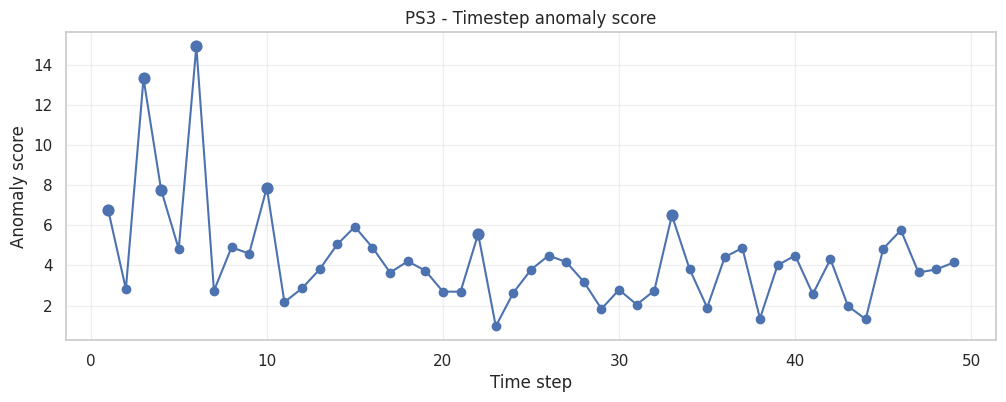

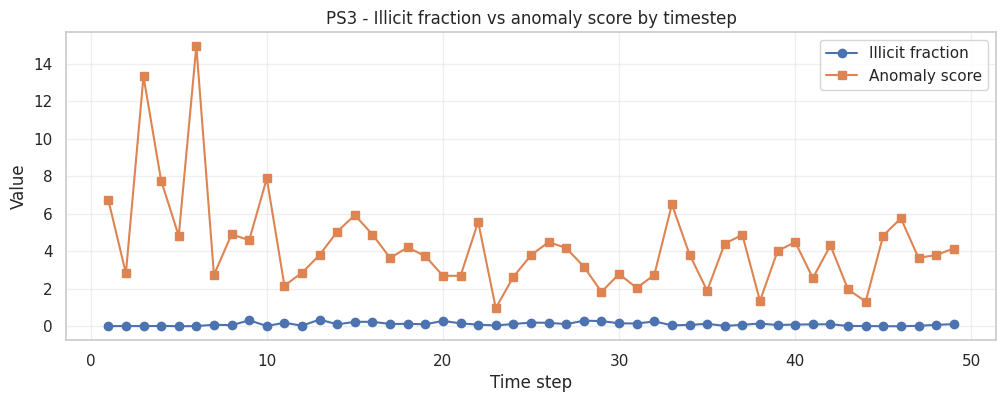

In [105]:
# =========================
# PS3 - STEP 13
# VISUALIZATION
# =========================

# (1) timestep anomaly score
plt.figure(figsize=(12, 4))
plt.plot(ps3_timestep_eval_df["time_step"], ps3_timestep_eval_df["timestep_anomaly_score"], marker="o")
plt.scatter(
    ps3_timestep_eval_df.loc[ps3_timestep_eval_df["timestep_anomaly_flag"] == 1, "time_step"],
    ps3_timestep_eval_df.loc[ps3_timestep_eval_df["timestep_anomaly_flag"] == 1, "timestep_anomaly_score"],
    s=60
)
plt.title("PS3 - Timestep anomaly score")
plt.xlabel("Time step")
plt.ylabel("Anomaly score")
plt.grid(True, alpha=0.3)
plt.show()

# (2) illicit fraction vs anomaly score
plt.figure(figsize=(12, 4))
plt.plot(ps3_timestep_eval_df["time_step"], ps3_timestep_eval_df["illicit_frac_t"], marker="o", label="Illicit fraction")
plt.plot(ps3_timestep_eval_df["time_step"], ps3_timestep_eval_df["timestep_anomaly_score"], marker="s", label="Anomaly score")
plt.title("PS3 - Illicit fraction vs anomaly score by timestep")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Step 14 — Three-way robustness check**

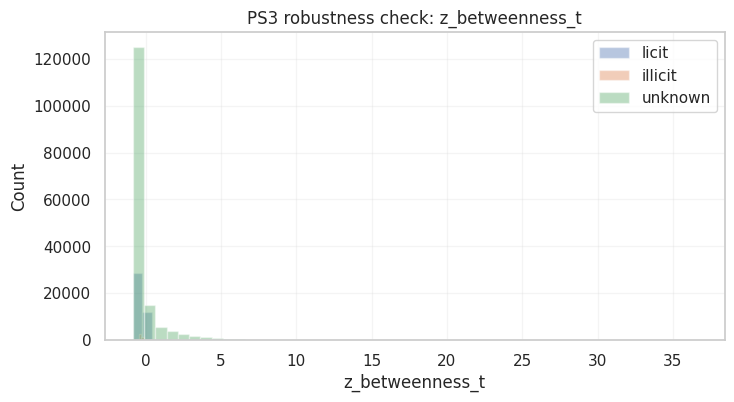

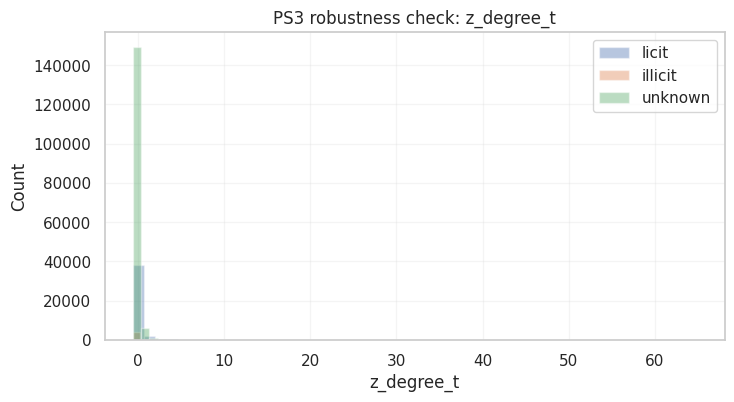

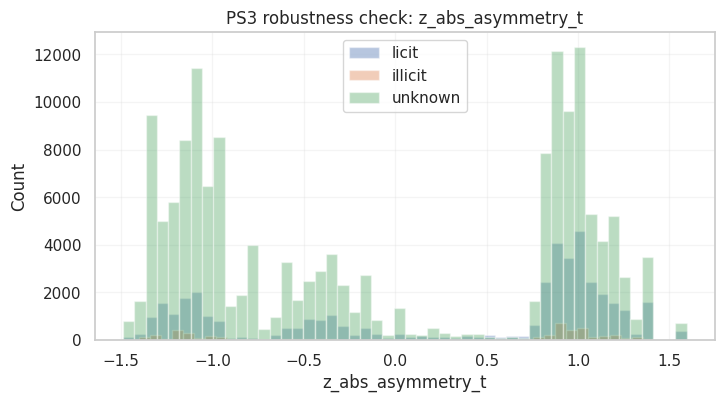

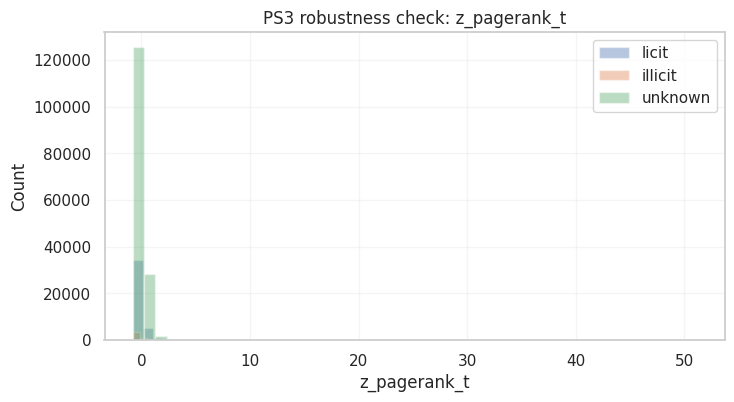

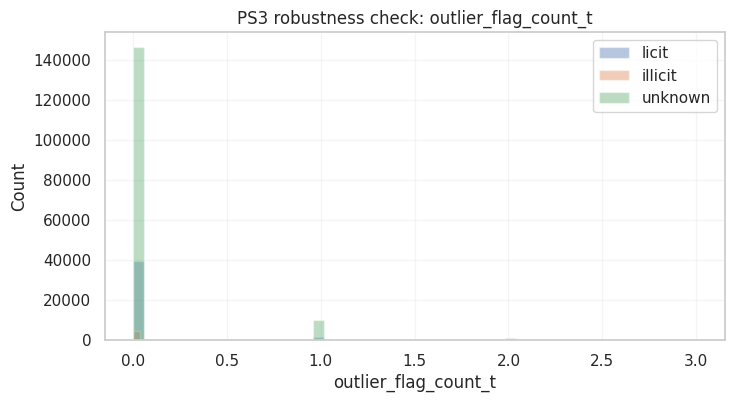

In [106]:
# =========================
# PS3 - STEP 14
# THREE-WAY ROBUSTNESS CHECK
# =========================

metrics_for_robustness = [
    "z_betweenness_t",
    "z_degree_t",
    "z_abs_asymmetry_t",
    "z_pagerank_t",
    "outlier_flag_count_t"
]

for metric in metrics_for_robustness:
    plt.figure(figsize=(8, 4))
    for cls in ["licit", "illicit", "unknown"]:
        vals = ps3_eval_df.loc[ps3_eval_df[CLASS_COL] == cls, metric].dropna()
        plt.hist(vals, bins=50, alpha=0.4, label=cls)
    plt.title(f"PS3 robustness check: {metric}")
    plt.xlabel(metric)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()